In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines
import numpy as np

# =========================
# 🔹 PADRÃO VISUAL DO TCC
# =========================

mpl.rcParams.update({
    # 🔹 Fonte
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],  # fallback se a 1ª não existir no sistema
    "mathtext.fontset": "stix",  # deixa fórmulas/matemática com aparência serifada compatível

    # 🔹 Tamanhos
    "font.size": 10,
    "axes.titlesize": 18,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
    "figure.titlesize": 25,

    # 🔹 Linhas e marcadores
    "lines.linewidth": 1.3,
    "lines.markersize": 4,

    # 🔹 Eixos e grid
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,

    # 🔹 Legenda
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "black",

    # 🔹 Exportação
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.dpi": 100,   # resolução na tela/notebook
})

# 🔹 paleta de cores consistente (colorblind-friendly)
PALETTE = {
    "Train": "#025C91",   # 
    "Val":   "#AD0283",   # 
    "Test":  "#5B02C0",   # 
    "Ref":   "black",
}

TITLE_LATEX = {
    "ZZxReto":   r"$ZZX_{reto}$",
    "ZZy1":      r"$ZZY_{1}$",
    "ZZx1":      r"$ZZX_{1}$",
    "ZZx2":      r"$ZZX_{2}$",
    "ZZy2":      r"$ZZY_{2}$",
    "ZZx1-inv":  r"$ZZX_{1}^{inv}$",
    "zzx2-inv2": r"$ZZX_{2}^{inv}$",
    "LSG-1":     r"$LSG_{1}$",
    "LSG-2":     r"$LSG_{2}$",
    "semiCirc":  r"$SCIRC$",
}

Abas encontradas no arquivo: ['LSG-1', 'LSG-2', 'ZZx1-inv', 'ZZx1', 'ZZx2-inv', 'ZZx2', 'ZZxReto', 'ZZy1', 'ZZy2', 'semiCirc', 'zzx2-inv2']


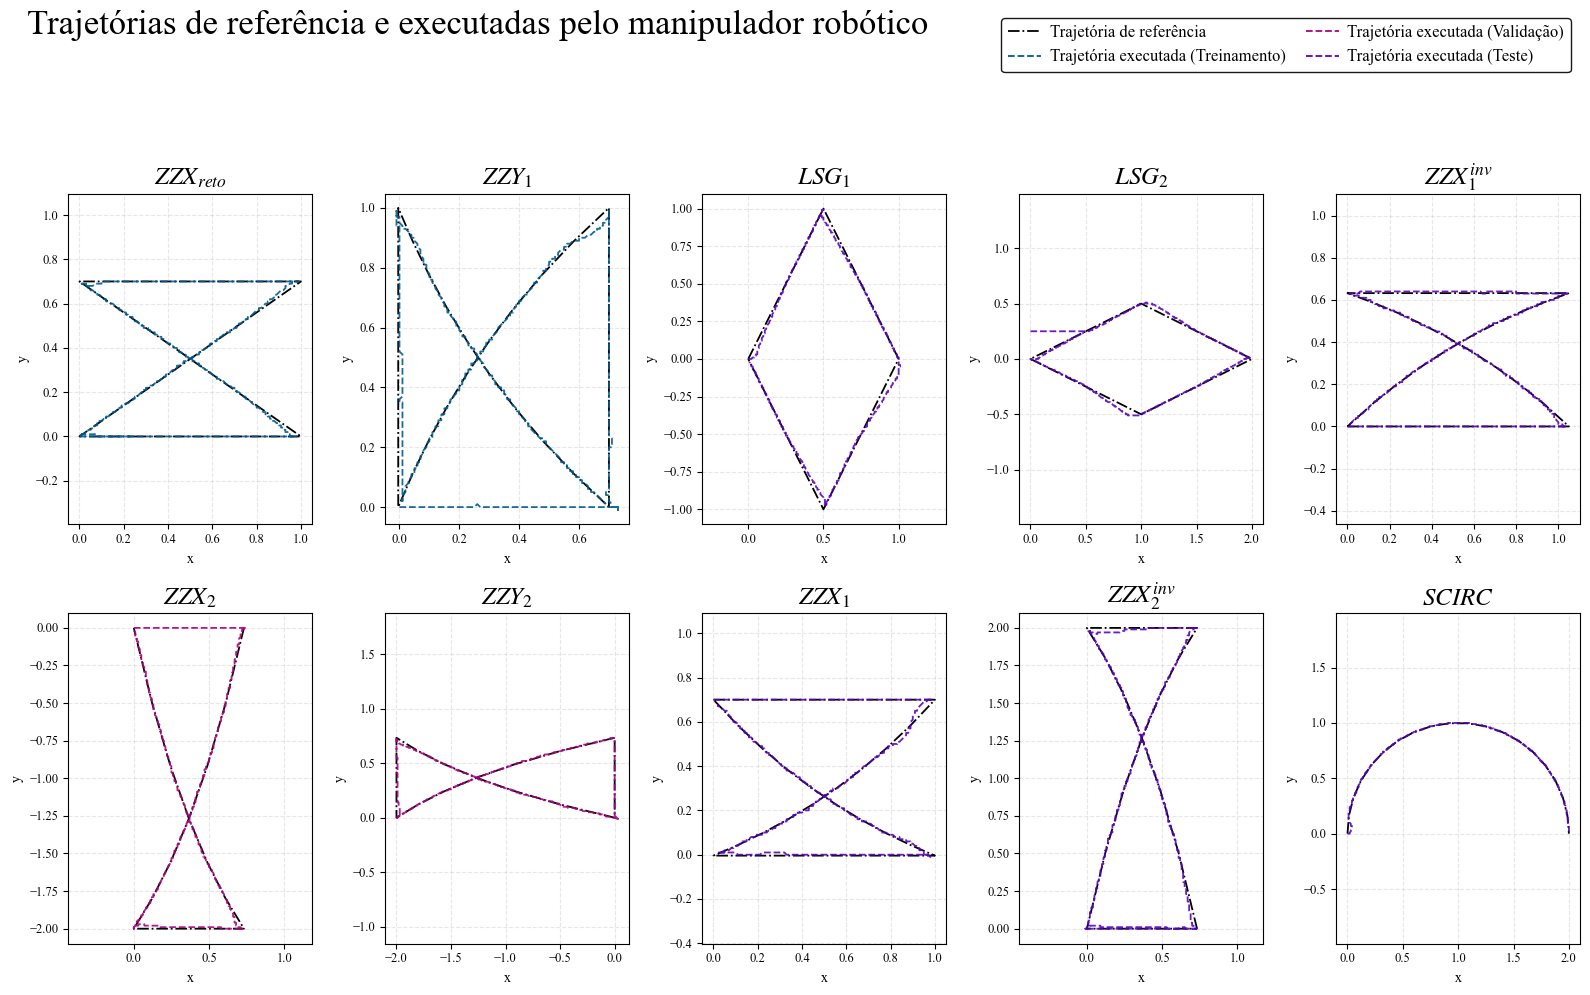


✅ Figura exportada em: trajetorias_referencia_vs_robo.pdf


In [39]:

# =========================
# 🔹 CONFIGURAÇÃO
# =========================

X_COL = "x"
Y_COL = "y"

FILE_PATH = "Datasets.xlsx"
OUTPUT_PDF = "trajetorias_referencia_vs_robo.pdf"

SETS_CATEGORY = {
    "ZZxReto":   "Train",
    "ZZy1":      "Train",
    "LSG-1":     "Test",
    "LSG-2":     "Test",
    "ZZx1-inv":  "Test",
    "ZZx2":      "Val",
    "ZZy2":      "Val",
    "ZZx1":      "Test",
    "zzx2-inv2": "Test",
    "semiCirc":  "Test",
}

CATEGORY_LABEL = {
    "Train": "Treinamento",
    "Val":   "Validação",
    "Test":  "Teste",
}

# =========================
# 🔹 TRAJETÓRIAS DE REFERÊNCIA (objVect)
# =========================

OBJ_VECTORS = {
    "ZZxReto": [
        (0.25,0),(0.5,0),(0.75,0),(1,0),(0.75,0.175),(0.5,0.35),(0.25,0.525),
        (0,0.7),(0.25,0.7),(0.5,0.7),(0.75,0.7),(1,0.7),(0.75,0.525),(0.5,0.35),
        (0.25,0.175),(0,0),(0.25,0),
    ],
    "ZZx1": [
        (0.0000,0.7000),(1.0000,0.7000),(0.8889,0.5829),(0.7778,0.4780),(0.6667,0.3842),
        (0.5556,0.3002),(0.4445,0.2251),(0.3333,0.1579),(0.2222,0.0978),(0.1111,0.0439),
        (0.0000,-0.0042),(1.0000,-0.0042),(0.8889,0.0439),(0.7778,0.0978),(0.6667,0.1579),
        (0.5556,0.2251),(0.4445,0.3002),(0.3333,0.3842),(0.2222,0.4780),(0.1111,0.5829),(0.0000,0.7000),
    ],
    "ZZy1": [
        (0.7000,0.0000),(0.7000,1.0000),(0.5829,0.8889),(0.4780,0.7778),(0.3842,0.6667),
        (0.3002,0.5556),(0.2251,0.4445),(0.1579,0.3333),(0.0978,0.2222),(0.0439,0.1111),
        (-0.0042,0.0000),(-0.0042,1.0000),(0.0439,0.8889),(0.0978,0.7778),(0.1579,0.6667),
        (0.2251,0.5556),(0.3002,0.4445),(0.3842,0.3333),(0.4780,0.2222),(0.5829,0.1111),(0.7000,0.0000),
    ],
    "ZZy2": [
        (-0.0000,0.7324),(-0.5020,0.6103),(-0.9199,0.4883),(-1.2679,0.3662),(-1.5578,0.2441),
        (-1.7991,0.1221),(-2.0000,0.0000),(-2.0000,0.7324),(-1.7991,0.6103),(-1.5578,0.4883),
        (-1.2679,0.3662),(-0.9199,0.2441),(-0.5020,0.1221),(-0.0000,0.0000),(-0.0000,0.7324),
    ],
    "ZZx1-inv": [
        (0.0000,0.0000),(1.0500,0.0000),(0.9333,0.1052),(0.8167,0.1993),(0.7000,0.2835),
        (0.5833,0.3588),(0.4667,0.4262),(0.3500,0.4866),(0.2333,0.5406),(0.1167,0.5889),
        (0.0000,0.6321),(1.0500,0.6321),(0.9333,0.5889),(0.8167,0.5406),(0.7000,0.4866),
        (0.5833,0.4262),(0.4667,0.3588),(0.3500,0.2835),(0.2333,0.1993),(0.1167,0.1052),
        (0.0000,0.0000),(0.0000,0.0000),
    ],
    "ZZx2": [
        (0.7324,-0.0000),(0.6103,-0.5020),(0.4883,-0.9199),(0.3662,-1.2679),(0.2441,-1.5578),
        (0.1221,-1.7991),(0.0000,-2.0000),(0.7324,-2.0000),(0.6103,-1.7991),(0.4883,-1.5578),
        (0.3662,-1.2679),(0.2441,-0.9199),(0.1221,-0.5020),(0.0000,-0.0000),
    ],
    "zzx2-inv2": [
        (0.7324,0.0000),(0.6103,0.5020),(0.4883,0.9199),(0.3662,1.2679),(0.2441,1.5578),
        (0.1221,1.7991),(0.0000,2.0000),(0.7324,2.0000),(0.6103,1.7991),(0.4883,1.5578),
        (0.3662,1.2679),(0.2441,0.9199),(0.1221,0.5020),(0.0000,0.0000),(0.7324,0.0000),
    ],
    "LSG-1": [
        (0.0,0.0),(0.25,0.5),(0.5,1),(0.75,0.5),(1,0),(0.75,-0.5),(0.5,-1),(0.25,-0.5),(0,0),
    ],
    "LSG-2": [
        (0.5,0.25),(1,0.5),(1.5,0.25),(2,0),(1.5,-0.25),(1,-0.5),(0.5,-0.25),(0,0),(0.5,0.25),
    ],
    "semiCirc": [
        (0.0000,0.0000),(0.0136,0.1646),(0.0542,0.3247),(0.1205,0.4759),(0.2109,0.6142),
        (0.3227,0.7357),(0.4531,0.8372),(0.5983,0.9158),(0.7545,0.9694),(0.9174,0.9966),
        (1.0826,0.9966),(1.2455,0.9694),(1.4017,0.9158),(1.5469,0.8372),(1.6773,0.7357),
        (1.7891,0.6142),(1.8795,0.4759),(1.9458,0.3247),(1.9864,0.1646),(2.0000,0.0000),
    ],
}

# =========================
# 🔹 LEITURA DOS DADOS DO ROBÔ
# =========================

xls = pd.ExcelFile(FILE_PATH)
print("Abas encontradas no arquivo:", xls.sheet_names)

TITLES_ORDER = list(SETS_CATEGORY.keys())

n_rows, n_cols = 2, 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 10), squeeze=False)
axs_flat = axs.flatten()

for i, title in enumerate(TITLES_ORDER):

    ax = axs_flat[i]
    category = SETS_CATEGORY[title]
    color = PALETTE.get(category, "gray")
    label_pt = CATEGORY_LABEL.get(category, category)

    # 🔹 trajetória de referência
    ref = np.array(OBJ_VECTORS[title])
    ax.plot(
        ref[:, 0], ref[:, 1],
        color=PALETTE["Ref"], linestyle="-.",
    )

    # 🔹 trajetória executada pelo robô
    if title in xls.sheet_names:
        df = xls.parse(title)
        if X_COL in df.columns and Y_COL in df.columns:
            ax.plot(
                df[X_COL], df[Y_COL],
                color=color, linestyle="--", alpha=0.9,
            )
        else:
            ax.text(0.5, 0.5, "Colunas X/Y não encontradas",
                    transform=ax.transAxes, ha="center", color="red")
    else:
        ax.text(0.5, 0.5, "Aba não encontrada",
                transform=ax.transAxes, ha="center", color="red")

    ax.set_title(f"{TITLE_LATEX[title]}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="datalim")

# =========================
# 🔹 LEGENDA ÚNICA + TÍTULO FORMAL
# =========================

legend_handles = [
    mlines.Line2D([], [], color=PALETTE["Ref"], linestyle="-.",
                  label="Trajetória de referência"),
    mlines.Line2D([], [], color=PALETTE["Train"], linestyle="--",
                  label="Trajetória executada (Treinamento)"),
    mlines.Line2D([], [], color=PALETTE["Val"], linestyle="--",
                  label="Trajetória executada (Validação)"),
    mlines.Line2D([], [], color=PALETTE["Test"], linestyle="--",
                  label="Trajetória executada (Teste)"),
]

fig.suptitle(
    "Trajetórias de referência e executadas pelo manipulador robótico",
    x=0.02, y=0.99, ha="left",
)

fig.legend(
    handles=legend_handles,
    # loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.5,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(OUTPUT_PDF, format="pdf")
plt.show()

print(f"\n✅ Figura exportada em: {OUTPUT_PDF}")

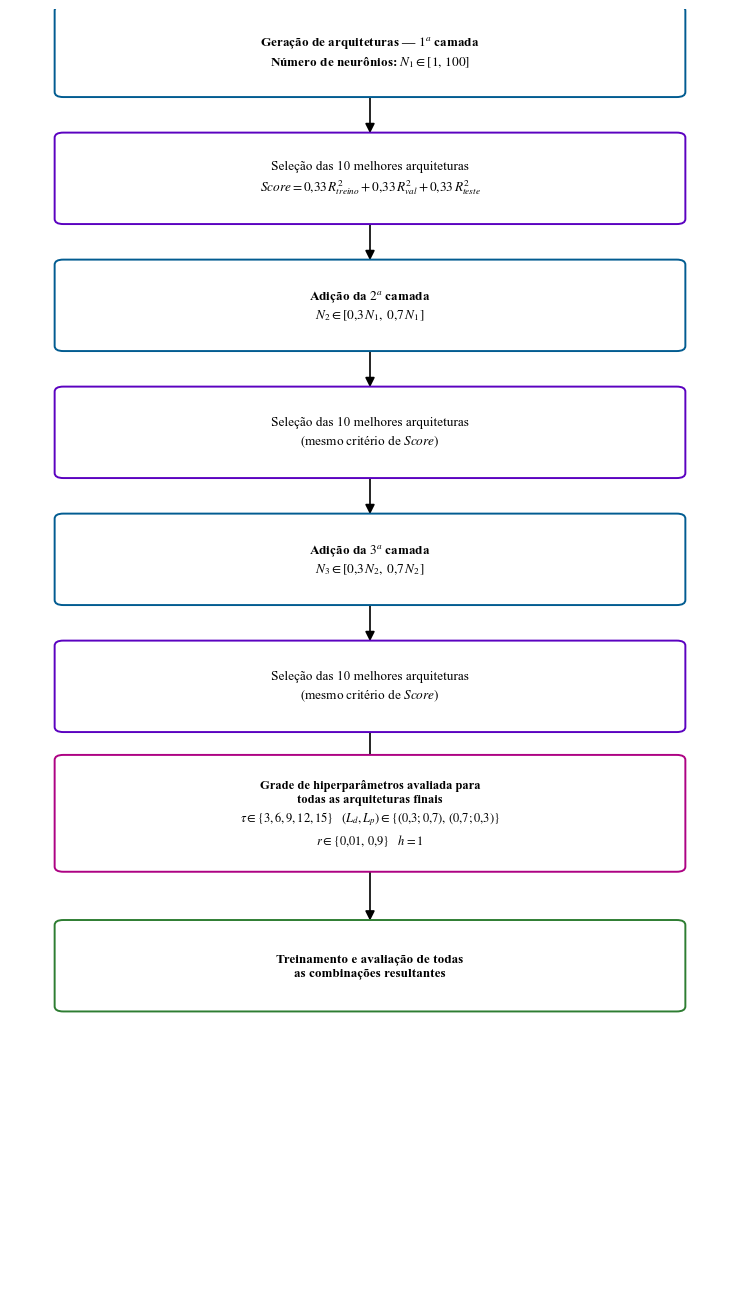


✅ Figura exportada em: metodologia_treinamento.pdf


In [40]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# =========================
# 🔹 PADRÃO VISUAL DO TCC
# =========================

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.dpi": 100,
})

PALETTE = {
    "gen":   "#025C91",   # geração de arquiteturas
    "sel":   "#5B02C0",   # seleção dos melhores modelos
    "grid":  "#AD0283",   # grade de hiperparâmetros
    "final": "#2E7D32",   # treinamento final
    "text":  "black",
}

OUTPUT_PDF = "metodologia_treinamento.pdf"

# =========================
# 🔹 FUNÇÕES AUXILIARES
# =========================

def add_box(ax, xy, width, height, text, color, fontsize=9.5, fontweight="normal"):
    x, y = xy
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        linewidth=1.4,
        edgecolor=color,
        facecolor="white",
        zorder=2,
    )
    ax.add_patch(box)
    ax.text(
        x, y, text,
        ha="center", va="center",
        fontsize=fontsize, fontweight=fontweight,
        color="black", zorder=3,
        linespacing=1.4,
    )
    return (x, y - height / 2), (x, y + height / 2)  # bottom, top


def add_arrow(ax, start, end, color="black"):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="-|>", mutation_scale=14,
        linewidth=1.2, color=color, zorder=1,
    )
    ax.add_patch(arrow)


# =========================
# 🔹 FIGURA
# =========================

fig, ax = plt.subplots(figsize=(7.5, 13))
ax.set_xlim(0, 10)
ax.set_ylim(0, 30)
ax.axis("off")

x_center = 5
box_w = 8.6
box_h = 2.0
gap = 1.0

y = 29
positions = {}

# --- Etapa 1: geração 1ª camada ---
bottom, top = add_box(
    ax, (x_center, y), box_w, box_h,
    "Geração de arquiteturas — $1^{a}$ camada\n"
    "Número de neurônios: $N_1 \\in [1,\\,100]$",
    PALETTE["gen"], fontweight="bold"
)
y -= (box_h + gap)

# --- Etapa 2: seleção top 10 (1 camada) ---
add_arrow(ax, bottom, (x_center, y + box_h / 2))
bottom, top = add_box(
    ax, (x_center, y), box_w, box_h,
    "Seleção das 10 melhores arquiteturas\n"
    "$Score = 0{,}33\\,R^2_{treino} + 0{,}33\\,R^2_{val} + 0{,}33\\,R^2_{teste}$",
    PALETTE["sel"]
)
y -= (box_h + gap)

# --- Etapa 3: adição 2ª camada ---
add_arrow(ax, bottom, (x_center, y + box_h / 2))
bottom, top = add_box(
    ax, (x_center, y), box_w, box_h,
    "Adição da $2^{a}$ camada\n"
    "$N_2 \\in [0{,}3\\,N_1,\\; 0{,}7\\,N_1]$",
    PALETTE["gen"], fontweight="bold"
)
y -= (box_h + gap)

# --- Etapa 4: seleção top 10 (2 camadas) ---
add_arrow(ax, bottom, (x_center, y + box_h / 2))
bottom, top = add_box(
    ax, (x_center, y), box_w, box_h,
    "Seleção das 10 melhores arquiteturas\n"
    "(mesmo critério de $Score$)",
    PALETTE["sel"]
)
y -= (box_h + gap)

# --- Etapa 5: adição 3ª camada ---
add_arrow(ax, bottom, (x_center, y + box_h / 2))
bottom, top = add_box(
    ax, (x_center, y), box_w, box_h,
    "Adição da $3^{a}$ camada\n"
    "$N_3 \\in [0{,}3\\,N_2,\\; 0{,}7\\,N_2]$",
    PALETTE["gen"], fontweight="bold"
)
y -= (box_h + gap)

# --- Etapa 6: seleção top 10 (3 camadas) ---
add_arrow(ax, bottom, (x_center, y + box_h / 2))
bottom, top = add_box(
    ax, (x_center, y), box_w, box_h,
    "Seleção das 10 melhores arquiteturas\n"
    "(mesmo critério de $Score$)",
    PALETTE["sel"]
)
y -= (box_h + gap)

# --- Etapa 7: grade de hiperparâmetros ---
add_arrow(ax, bottom, (x_center, y + box_h / 2))
bottom, top = add_box(
    ax, (x_center, y), box_w, box_h + 0.6,
    "Grade de hiperparâmetros avaliada para\n"
    "todas as arquiteturas finais\n"
    "$\\tau \\in \\{3,6,9,12,15\\} \\quad$"
    "$(L_d, L_p) \\in \\{(0{,}3;0{,}7),\\,(0{,}7;0{,}3)\\}$\n"
    "$r \\in \\{0{,}01,\\,0{,}9\\} \\quad h = 1$",
    PALETTE["grid"], fontweight="bold", fontsize=9
)
y -= (box_h + 0.6 + gap)

# --- Etapa 8: treinamento final ---
add_arrow(ax, bottom, (x_center, y + box_h / 2))
add_box(
    ax, (x_center, y), box_w, box_h,
    "Treinamento e avaliação de todas\n"
    "as combinações resultantes",
    PALETTE["final"], fontweight="bold"
)

plt.tight_layout()
plt.savefig(OUTPUT_PDF, format="pdf")
plt.show()

print(f"\n✅ Figura exportada em: {OUTPUT_PDF}")